# MaxViT による BIAS-PROFS データセットの学習

## 1. 必要ライブラリのインポート

In [1]:
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import timm
from torchvision import transforms

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter Notebook 用の進捗バー
from tqdm.auto import tqdm
from IPython.display import display, clear_output

# 日本語文字化け対策
try:
    import japanize_matplotlib  # noqa: F401
except ImportError:
    plt.rcParams['font.family'] = ['IPAexGothic', 'Noto Sans CJK JP', 'MS Gothic', 'Hiragino Sans', 'sans-serif']
    plt.rcParams['axes.unicode_minus'] = False

from safetensors.torch import save_file

## 2. 再現性のためにシード値固定 および `DEVICE` の設定

In [2]:
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 3. ハイパーパラメータ設定

In [3]:
IMAGE_DIR = Path("../images/bias-profs")
LABEL_CSV = Path("../labels/bias-profs-labels.csv")
MODEL_SAVE_DIR = Path("../models/maxvit-bias-profs")
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "maxvit_small_tf_224"
IMG_SIZE = 224
NUM_CLASSES = 5
CLASS_NAMES = ["A", "B", "C", "D", "E"]

LR = 5e-5
BATCH_SIZE = 16
EPOCHS = 20
WEIGHT_DECAY = 1e-4
N_SPLITS = 5
NUM_WORKERS = 0  # Windows では 0 にしないとエラーが置きます
USE_FP16 = True

## 4. ラベル CSV の読み込み

In [4]:
df = pd.read_csv(LABEL_CSV)
print(f"データ件数: {len(df)}")
print(df.head())
print("\nクラス分布:")
print(df["Class"].value_counts().sort_index())

class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
df["label"] = df["Class"].map(class_to_idx)

データ件数: 7716
   ID Class
0   1     A
1   2     A
2   3     A
3   4     A
4   5     A

クラス分布:
Class
A    5302
B     454
C    1929
D      13
E      18
Name: count, dtype: int64


## 5. `Dataset` の定義

In [5]:
class GPCRGraphDataset(Dataset):
    """
    アミノ酸配列をグラフ画像化したデータセット。
    グレースケール画像を3チャネルに複製して MaxViT に入力する。
    """
    def __init__(self, ids, labels, image_dir, transform=None):
        self.ids = ids
        self.labels = labels
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        label = self.labels[idx]
        img_path = self.image_dir / f"{img_id}.png"

        # グレースケールで読み込み -> RGB に複製
        image = Image.open(img_path).convert("L").convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

## 6. データ変換（timm のデフォルト統計値を使用）

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

## 7. 学習・評価ループ用関数

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, use_fp16=True, pbar=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        if use_fp16:
            with autocast(device):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

        if pbar is not None:
            pbar.update(1)
            pbar.set_postfix({
                "loss": f"{running_loss / total:.4f}",
                "acc":  f"{correct / total:.4f}",
            })

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, use_fp16=True, pbar=None):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_fp16:
            with autocast(device):
                outputs = model(images)
                loss = criterion(outputs, labels)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if pbar is not None:
            pbar.update(1)

    avg_loss = running_loss / total
    accuracy = correct / total
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, accuracy, macro_precision, macro_recall, macro_f1, all_preds, all_labels

## 8. エポック結果テーブル表示用

In [8]:
def format_epoch_table(history_records):
    """各エポックの記録（list of dict）を DataFrame にして表示する。"""
    df_log = pd.DataFrame(history_records)
    # 表示順を整える
    cols = ["Epoch", "Train Loss", "Val Loss", "Train Acc", "Val Acc",
            "Precision", "Recall", "Macro F1"]
    df_log = df_log[cols]
    # 小数点フォーマット
    return df_log.style.format({
        "Train Loss": "{:.4f}",
        "Val Loss":   "{:.4f}",
        "Train Acc":  "{:.4f}",
        "Val Acc":    "{:.4f}",
        "Precision":  "{:.4f}",
        "Recall":     "{:.4f}",
        "Macro F1":   "{:.4f}",
    }).hide(axis="index")

## 9. 5分割交差検証を行う

In [9]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

ids_all = df["ID"].values
labels_all = df["label"].values

fold_histories = []
fold_final_metrics = []
fold_predictions = []
best_fold_idx = -1
best_macro_f1 = -1.0
best_model_state = None

# 全体進捗バー（Fold単位）
fold_bar = tqdm(total=N_SPLITS, desc="Cross-Validation", position=0, leave=True)

for fold, (train_idx, val_idx) in enumerate(skf.split(ids_all, labels_all)):
    print(f"\n{'='*70}")
    print(f"Fold {fold + 1}/{N_SPLITS}")
    print(f"{'='*70}")

    train_ids = ids_all[train_idx]
    train_labels = labels_all[train_idx]
    val_ids = ids_all[val_idx]
    val_labels = labels_all[val_idx]

    train_dataset = GPCRGraphDataset(train_ids, train_labels, IMAGE_DIR, transform=train_transform)
    val_dataset = GPCRGraphDataset(val_ids, val_labels, IMAGE_DIR, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

    model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler = GradScaler(enabled=USE_FP16)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
               "precision": [], "recall": [], "macro_f1": []}
    epoch_records = []  # テーブル表示用

    # エポック単位の進捗バー（fold 内で再利用、leave=False で消える）
    epoch_bar = tqdm(total=EPOCHS, desc=f"Fold {fold+1} Epochs",
                     position=1, leave=False)

    # 結果テーブル表示エリアを確保
    from IPython.display import display
    import ipywidgets as widgets
    table_output = widgets.Output()
    display(table_output)

    steps_per_epoch = len(train_loader) + len(val_loader)

    for epoch in range(EPOCHS):
        # ステップ単位の進捗バー（エポックごとに作り直し、leave=False）
        step_bar = tqdm(total=steps_per_epoch,
                        desc=f"Epoch {epoch+1}/{EPOCHS}",
                        position=2, leave=False)

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device,
            use_fp16=USE_FP16, pbar=step_bar
        )
        val_loss, val_acc, val_prec, val_rec, val_macro_f1, _, _ = evaluate(
            model, val_loader, criterion, device, use_fp16=USE_FP16, pbar=step_bar
        )

        step_bar.close()

        # 履歴更新
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["precision"].append(val_prec)
        history["recall"].append(val_rec)
        history["macro_f1"].append(val_macro_f1)

        epoch_records.append({
            "Epoch":      epoch + 1,
            "Train Loss": train_loss,
            "Val Loss":   val_loss,
            "Train Acc":  train_acc,
            "Val Acc":    val_acc,
            "Precision":  val_prec,
            "Recall":     val_rec,
            "Macro F1":   val_macro_f1,
        })

        # テーブル更新（同じ場所に上書き）
        with table_output:
            clear_output(wait=True)
            print(f"=== Fold {fold + 1} - Epoch {epoch + 1}/{EPOCHS} 終了 ===")
            display(format_epoch_table(epoch_records))

        epoch_bar.update(1)

    epoch_bar.close()

    # 最終評価（混同行列用に predictions を保持）
    final_val_loss, final_val_acc, final_prec, final_rec, final_macro_f1, val_preds, val_true = evaluate(
        model, val_loader, criterion, device, use_fp16=USE_FP16
    )

    fold_histories.append(history)
    fold_final_metrics.append({
        "train_loss": history["train_loss"][-1],
        "val_loss":   final_val_loss,
        "train_acc":  history["train_acc"][-1],
        "val_acc":    final_val_acc,
        "precision":  final_prec,
        "recall":     final_rec,
        "macro_f1":   final_macro_f1,
    })
    fold_predictions.append((val_preds, val_true))

    print(f"\n[Fold {fold + 1}] 最終 Macro F1: {final_macro_f1:.4f}")

    if final_macro_f1 > best_macro_f1:
        best_macro_f1 = final_macro_f1
        best_fold_idx = fold
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    del model, optimizer, scaler, train_loader, val_loader
    torch.cuda.empty_cache()

    fold_bar.update(1)

fold_bar.close()

Cross-Validation:   0%|          | 0/5 [00:00<?, ?it/s]


Fold 1/5


C:\Users\ArchWizard7\AppData\Local\Temp\ipykernel_39520\2170423393.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_FP16)


Fold 1 Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Output()

...

Epoch 19/20:   0%|          | 0/483 [00:00<?, ?it/s]

C:\Users\ArchWizard7\AppData\Local\Temp\ipykernel_39520\3386279959.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\ArchWizard7\AppData\Local\Temp\ipykernel_39520\3386279959.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 20/20:   0%|          | 0/483 [00:00<?, ?it/s]

C:\Users\ArchWizard7\AppData\Local\Temp\ipykernel_39520\3386279959.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\ArchWizard7\AppData\Local\Temp\ipykernel_39520\3386279959.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\ArchWizard7\AppData\Local\Temp\ipykernel_39520\3386279959.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



[Fold 5] 最終 Macro F1: 0.8322


## 10. Best Model の保存 (.safetensors)

In [10]:
save_path = MODEL_SAVE_DIR / f"maxvit_small_tf_224_best_fold{best_fold_idx + 1}.safetensors"
state_dict_to_save = {k: v.contiguous() for k, v in best_model_state.items()}
save_file(state_dict_to_save, str(save_path))

print(f"\nBest Fold: {best_fold_idx + 1}")
print(f"Best Macro F1: {best_macro_f1:.4f}")
print(f"モデルを保存しました: {save_path}")


Best Fold: 2
Best Macro F1: 0.8967
モデルを保存しました: ..\models\maxvit-bias-profs\maxvit_small_tf_224_best_fold2.safetensors


## 11. 5分割の平均指標を表示

In [11]:
avg_train_loss = np.mean([m["train_loss"] for m in fold_final_metrics])
avg_val_loss   = np.mean([m["val_loss"]   for m in fold_final_metrics])
avg_train_acc  = np.mean([m["train_acc"]  for m in fold_final_metrics])
avg_val_acc    = np.mean([m["val_acc"]    for m in fold_final_metrics])
avg_precision  = np.mean([m["precision"]  for m in fold_final_metrics])
avg_recall     = np.mean([m["recall"]     for m in fold_final_metrics])
avg_macro_f1   = np.mean([m["macro_f1"]   for m in fold_final_metrics])

print("=" * 70)
print("5分割交差検証 平均結果")
print("=" * 70)
print(f"平均 Train Loss : {avg_train_loss:.4f}")
print(f"平均 Val Loss   : {avg_val_loss:.4f}")
print(f"平均 Train Acc  : {avg_train_acc:.4f}")
print(f"平均 Val Acc    : {avg_val_acc:.4f}")
print(f"平均 Precision  : {avg_precision:.4f}")
print(f"平均 Recall     : {avg_recall:.4f}")
print(f"平均 Macro F1   : {avg_macro_f1:.4f}")

print("\n各 Fold の最終指標:")
metrics_df = pd.DataFrame(fold_final_metrics, index=[f"Fold {i+1}" for i in range(N_SPLITS)])
display(metrics_df.round(4))

5分割交差検証 平均結果
平均 Train Loss : 0.0169
平均 Val Loss   : 0.1393
平均 Train Acc  : 0.9932
平均 Val Acc    : 0.9719
平均 Precision  : 0.8025
平均 Recall     : 0.7990
平均 Macro F1   : 0.7972

各 Fold の最終指標:


,train_loss,val_loss,train_acc,val_acc,precision,recall,macro_f1
Fold 1,0.0129,0.1671,0.9948,0.9702,0.7545,0.7709,0.7617
Fold 2,0.0193,0.1097,0.9921,0.9721,0.9070,0.8879,0.8967
Fold 3,0.0210,0.1236,0.9919,0.9708,0.7649,0.7079,0.7296
Fold 4,0.0090,0.1810,0.9948,0.9728,0.7735,0.7597,0.7659
Fold 5,0.0223,0.1150,0.9925,0.9734,0.8127,0.8684,0.8322


## 12. 学習曲線の描画（5本＋平均）

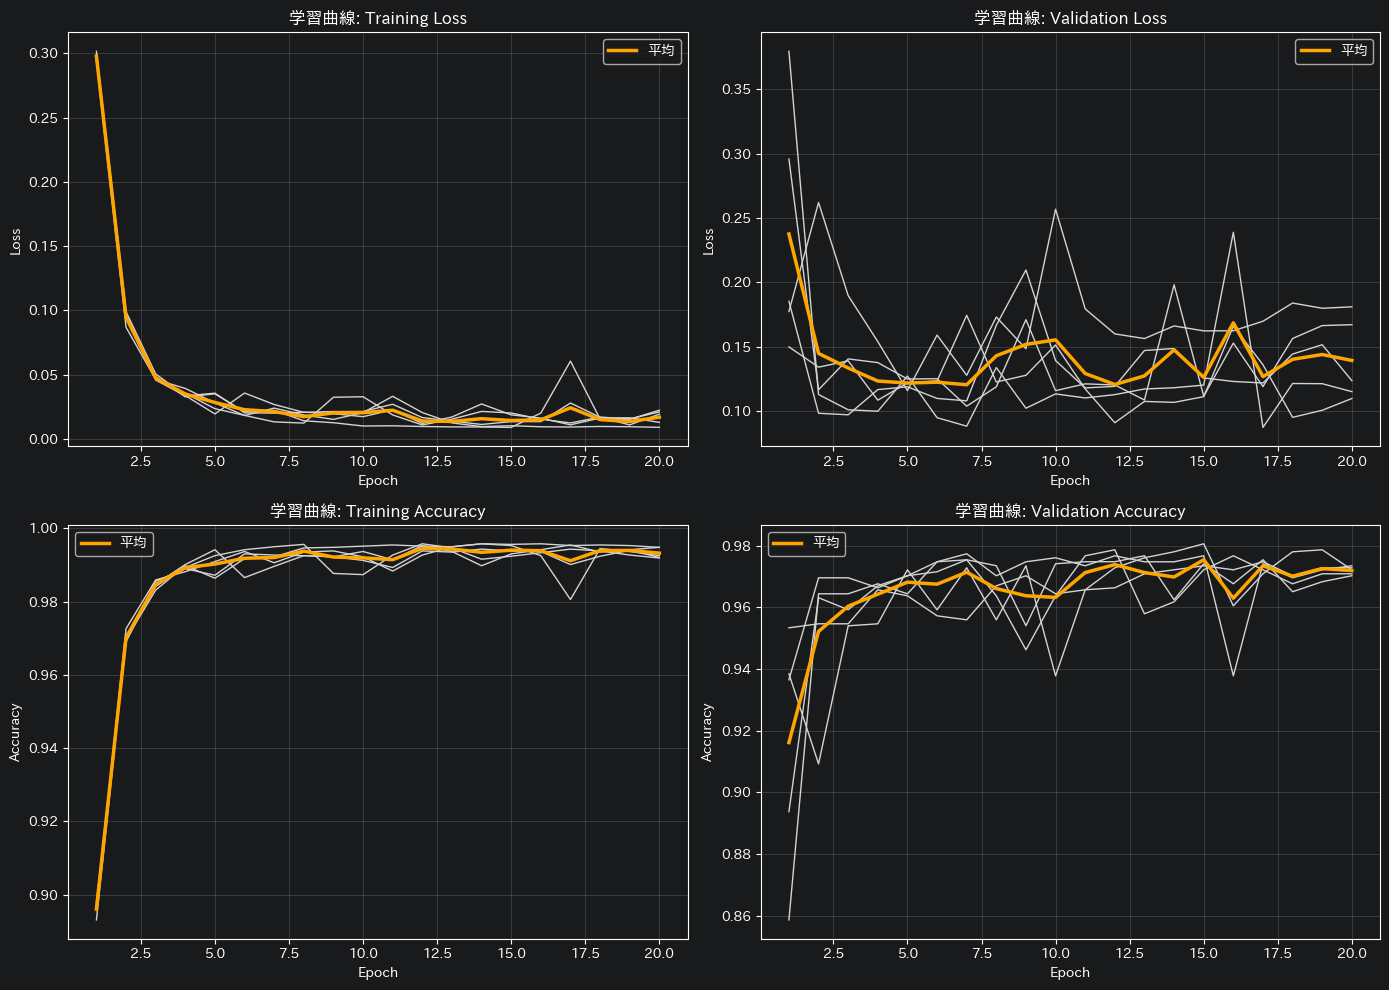

In [12]:
epochs_range = np.arange(1, EPOCHS + 1)

train_loss_arr = np.array([h["train_loss"] for h in fold_histories])
val_loss_arr   = np.array([h["val_loss"]   for h in fold_histories])
train_acc_arr  = np.array([h["train_acc"]  for h in fold_histories])
val_acc_arr    = np.array([h["val_acc"]    for h in fold_histories])

mean_train_loss = train_loss_arr.mean(axis=0)
mean_val_loss   = val_loss_arr.mean(axis=0)
mean_train_acc  = train_acc_arr.mean(axis=0)
mean_val_acc    = val_acc_arr.mean(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for i in range(N_SPLITS):
    ax.plot(epochs_range, train_loss_arr[i], color="lightgray", linewidth=1)
ax.plot(epochs_range, mean_train_loss, color="orange", linewidth=2.5, label="平均")
ax.set_title("学習曲線: Training Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
for i in range(N_SPLITS):
    ax.plot(epochs_range, val_loss_arr[i], color="lightgray", linewidth=1)
ax.plot(epochs_range, mean_val_loss, color="orange", linewidth=2.5, label="平均")
ax.set_title("学習曲線: Validation Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
for i in range(N_SPLITS):
    ax.plot(epochs_range, train_acc_arr[i], color="lightgray", linewidth=1)
ax.plot(epochs_range, mean_train_acc, color="orange", linewidth=2.5, label="平均")
ax.set_title("学習曲線: Training Accuracy")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
for i in range(N_SPLITS):
    ax.plot(epochs_range, val_acc_arr[i], color="lightgray", linewidth=1)
ax.plot(epochs_range, mean_val_acc, color="orange", linewidth=2.5, label="平均")
ax.set_title("学習曲線: Validation Accuracy")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. 混同行列の描画

C:\Users\ArchWizard7\AppData\Local\Temp\ipykernel_39520\3453249706.py:5: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_ratio = np.divide(cm_count, row_sums, where=row_sums != 0)


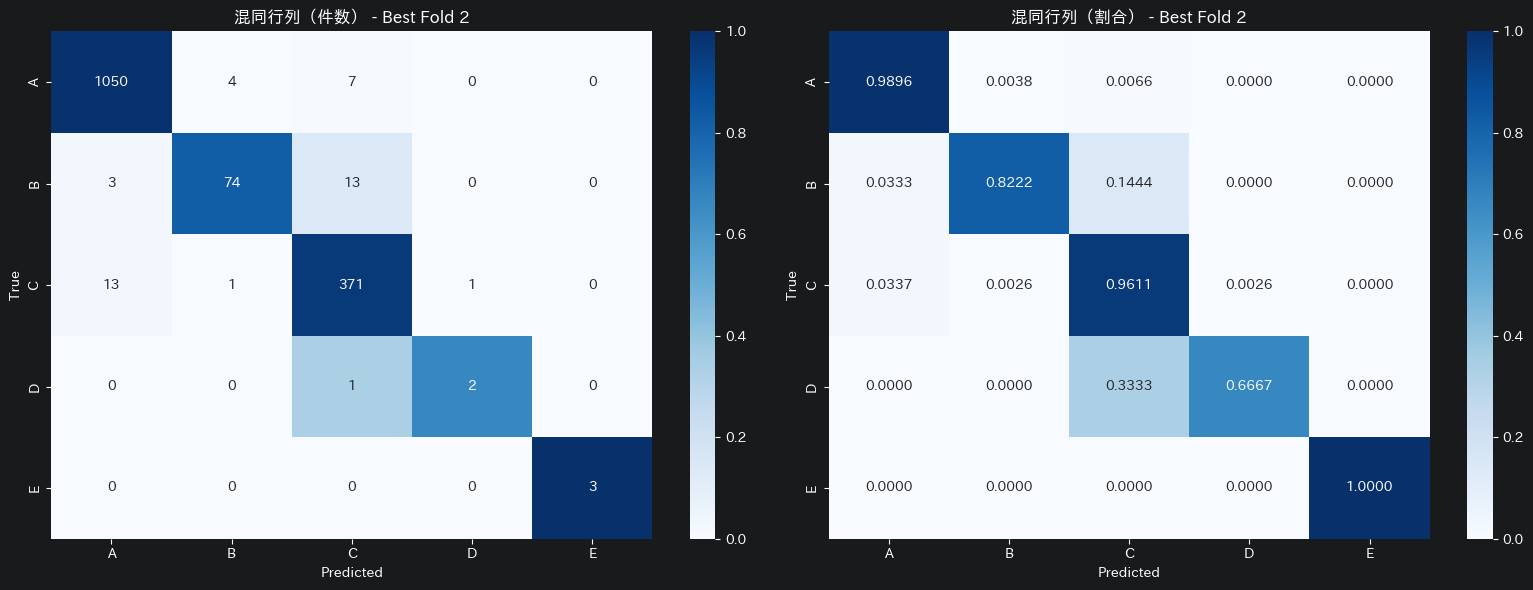

In [13]:
best_preds, best_true = fold_predictions[best_fold_idx]

cm_count = confusion_matrix(best_true, best_preds, labels=list(range(NUM_CLASSES)))
row_sums = cm_count.sum(axis=1, keepdims=True)
cm_ratio = np.divide(cm_count, row_sums, where=row_sums != 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.heatmap(
    cm_ratio, annot=cm_count, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cbar=True, vmin=0.0, vmax=1.0, ax=ax,
)
ax.set_title(f"混同行列（件数） - Best Fold {best_fold_idx + 1}")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")

ax = axes[1]
sns.heatmap(
    cm_ratio, annot=True, fmt=".4f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cbar=True, vmin=0.0, vmax=1.0, ax=ax,
)
ax.set_title(f"混同行列（割合） - Best Fold {best_fold_idx + 1}")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.tight_layout()
plt.show()

## 14. 詳細な分類レポート（Best Fold）

In [14]:
print(f"=== Best Fold {best_fold_idx + 1} - Classification Report ===")
print(classification_report(best_true, best_preds, target_names=CLASS_NAMES, digits=4))

=== Best Fold 2 - Classification Report ===
              precision    recall  f1-score   support

           A     0.9850    0.9896    0.9873      1061
           B     0.9367    0.8222    0.8757        90
           C     0.9464    0.9611    0.9537       386
           D     0.6667    0.6667    0.6667         3
           E     1.0000    1.0000    1.0000         3

    accuracy                         0.9721      1543
   macro avg     0.9070    0.8879    0.8967      1543
weighted avg     0.9719    0.9721    0.9718      1543

